# **Week4 (Classification) 과제**

# Red Wine Quality Classification

## 데이터 소개
  
UCI Machine Learning  
**TASK : Red wine Classification**  
https://archive.ics.uci.edu/dataset/186/wine+quality


csv 파일의 컬럼은 아래와 같습니다.

*   index : 구분자
*   quality : 품질
*   fixed acidity : 산도
*   volatile acidity : 휘발성산
*   citric acid : 시트르산
*   residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
*   chlorides : 염화물
*   free sulfur dioxide : 독립 이산화황
*   total sulfur dioxide : 총 이산화황
*   density : 밀도
*   pH : 수소이온농도
*   sulphates : 황산염
*   alcohol : 도수
*   type : 종류



In [ ]:
# 코랩 환경: 구글 드라이브에 코랩을 연동
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [4]:
# loading data ,your own file path
df = pd.read_csv('winequality-red.csv', sep=';')

## EDA(Exploratory Data Analysis)

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Q1 Data brief review : info() 함수를 통해 알아낼 수 있는 정보를 작성하시오. 
(**빈칸 ## 4개를 채우시오**)


답: It turns out that the dataset does not have (**null**) values. The dataset consists of (**1599**) rows and (**12**) columns. The data type of all variables are (**numeric**).



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Q2 결측치 확인
결측치가 존재한다면, 이를 처리하는 방법에 대해 알아보고 정리해주세요.

결측치는 판단에 따라 drop(제거) 할 수 있고, 특정 값으로 채울(대체) 수 있습니다.

데이터를 채우는 방법으로는 수치형 데이터는 통계를 이용해서, 범주형 데이터는 unique(), value_counts() 등으로 처리합니다.

In [8]:
# 결측치 확인
## df의 결측치의 총 합을 확인하는 코드를 작성하며, ##을 채우세요. sum()을 2번 사용하시오.

print("There are {} null values in the dataset".format(df.isnull().sum().sum()))

There are 0 null values in the dataset


`df.isnull()`은 각 데이터가 결측치인지 확인하여 결측치이면 `True`, 아니면 `False`를 반환한다.  
첫 번째 `sum()`은 `True`를 1로 계산하여 각 열의 결측치 개수를 구하고, 두 번째 `sum()`은 열별 결과를 다시 합하여 데이터셋 전체의 결측치 개수를 계산한다.

확인 결과 전체 결측치는 0개이므로 별도의 제거 또는 대체 처리가 필요하지 않다.

### Q3 데이터 분포 확인
각 변수의 데이터 분포가 어떠한지 기술하시오.(맨 위의 세개의 변수에 대해서만 기술)

1. `fixed acidity`: 대부분의 값이 약 6~10 사이에 분포하며, 값이 큰 방향으로 긴 꼬리를 가지는 우측 편향 분포를 보인다. 일부 와인에서는 12 이상의 높은 값이 나타나므로 이상치의 존재 가능성을 확인할 필요가 있다.

2. `volatile acidity`: 대부분의 값이 약 0.3~0.7 사이에 집중되어 있으며, 높은 값 방향으로 꼬리가 이어지는 약한 우측 편향 분포를 보인다. 1.0 이상인 일부 관측치는 상대적으로 드문 값이다.

3. `citric acid`: 값이 0~0.5 사이에 주로 분포하며, 0인 관측값도 다수 존재한다. 분포는 완전한 정규분포라기보다 여러 구간에 값이 모여 있고, 높은 값 방향으로 약간 치우쳐 있다.

각 변수에 대한 도메인 지식을 더 찾아보니 데이터 분포가 이렇게 나타나는 이유도 생각해 볼 수 있다.

1. `fixed acidity`: 고정산도는 주로 포도에 자연적으로 존재하는 주석산, 사과산 등 비휘발성 산의 영향을 받는다. 포도의 품종, 재배 환경, 수확 당시의 숙성도와 양조 과정에 따라 함량이 달라진다. 대부분의 와인이 비슷한 산도 범위에 모여 있지만, 일부 산도가 높은 포도 또는 산도 조정을 거친 와인으로 인해 높은 값 방향의 꼬리가 나타난 것으로 볼 수 있다.

2. `volatile acidity`: 휘발산도는 주로 발효 과정에서 생성되는 아세트산과 관련된다. 적정량은 일반적이지만, 미생물 활동이나 산소 노출 및 발효 관리 상태에 따라 증가할 수 있다. 따라서 대부분은 낮거나 중간 수준에 모이고, 일부 와인에서만 높은 값이 나타나는 우측 편향 분포가 형성된 것으로 해석할 수 있다.

3. `citric acid`: 구연산은 포도와 와인에 존재하지만 주석산이나 사과산보다 일반적으로 함량이 적다. 포도 품종과 숙성도에 따라 차이가 나며, 발효 과정에서 미생물에 의해 일부 소비될 수도 있다. 따라서 낮은 값과 0에 가까운 값이 많이 나타나고, 일부 와인만 비교적 높은 값을 가진 것으로 볼 수 있다.

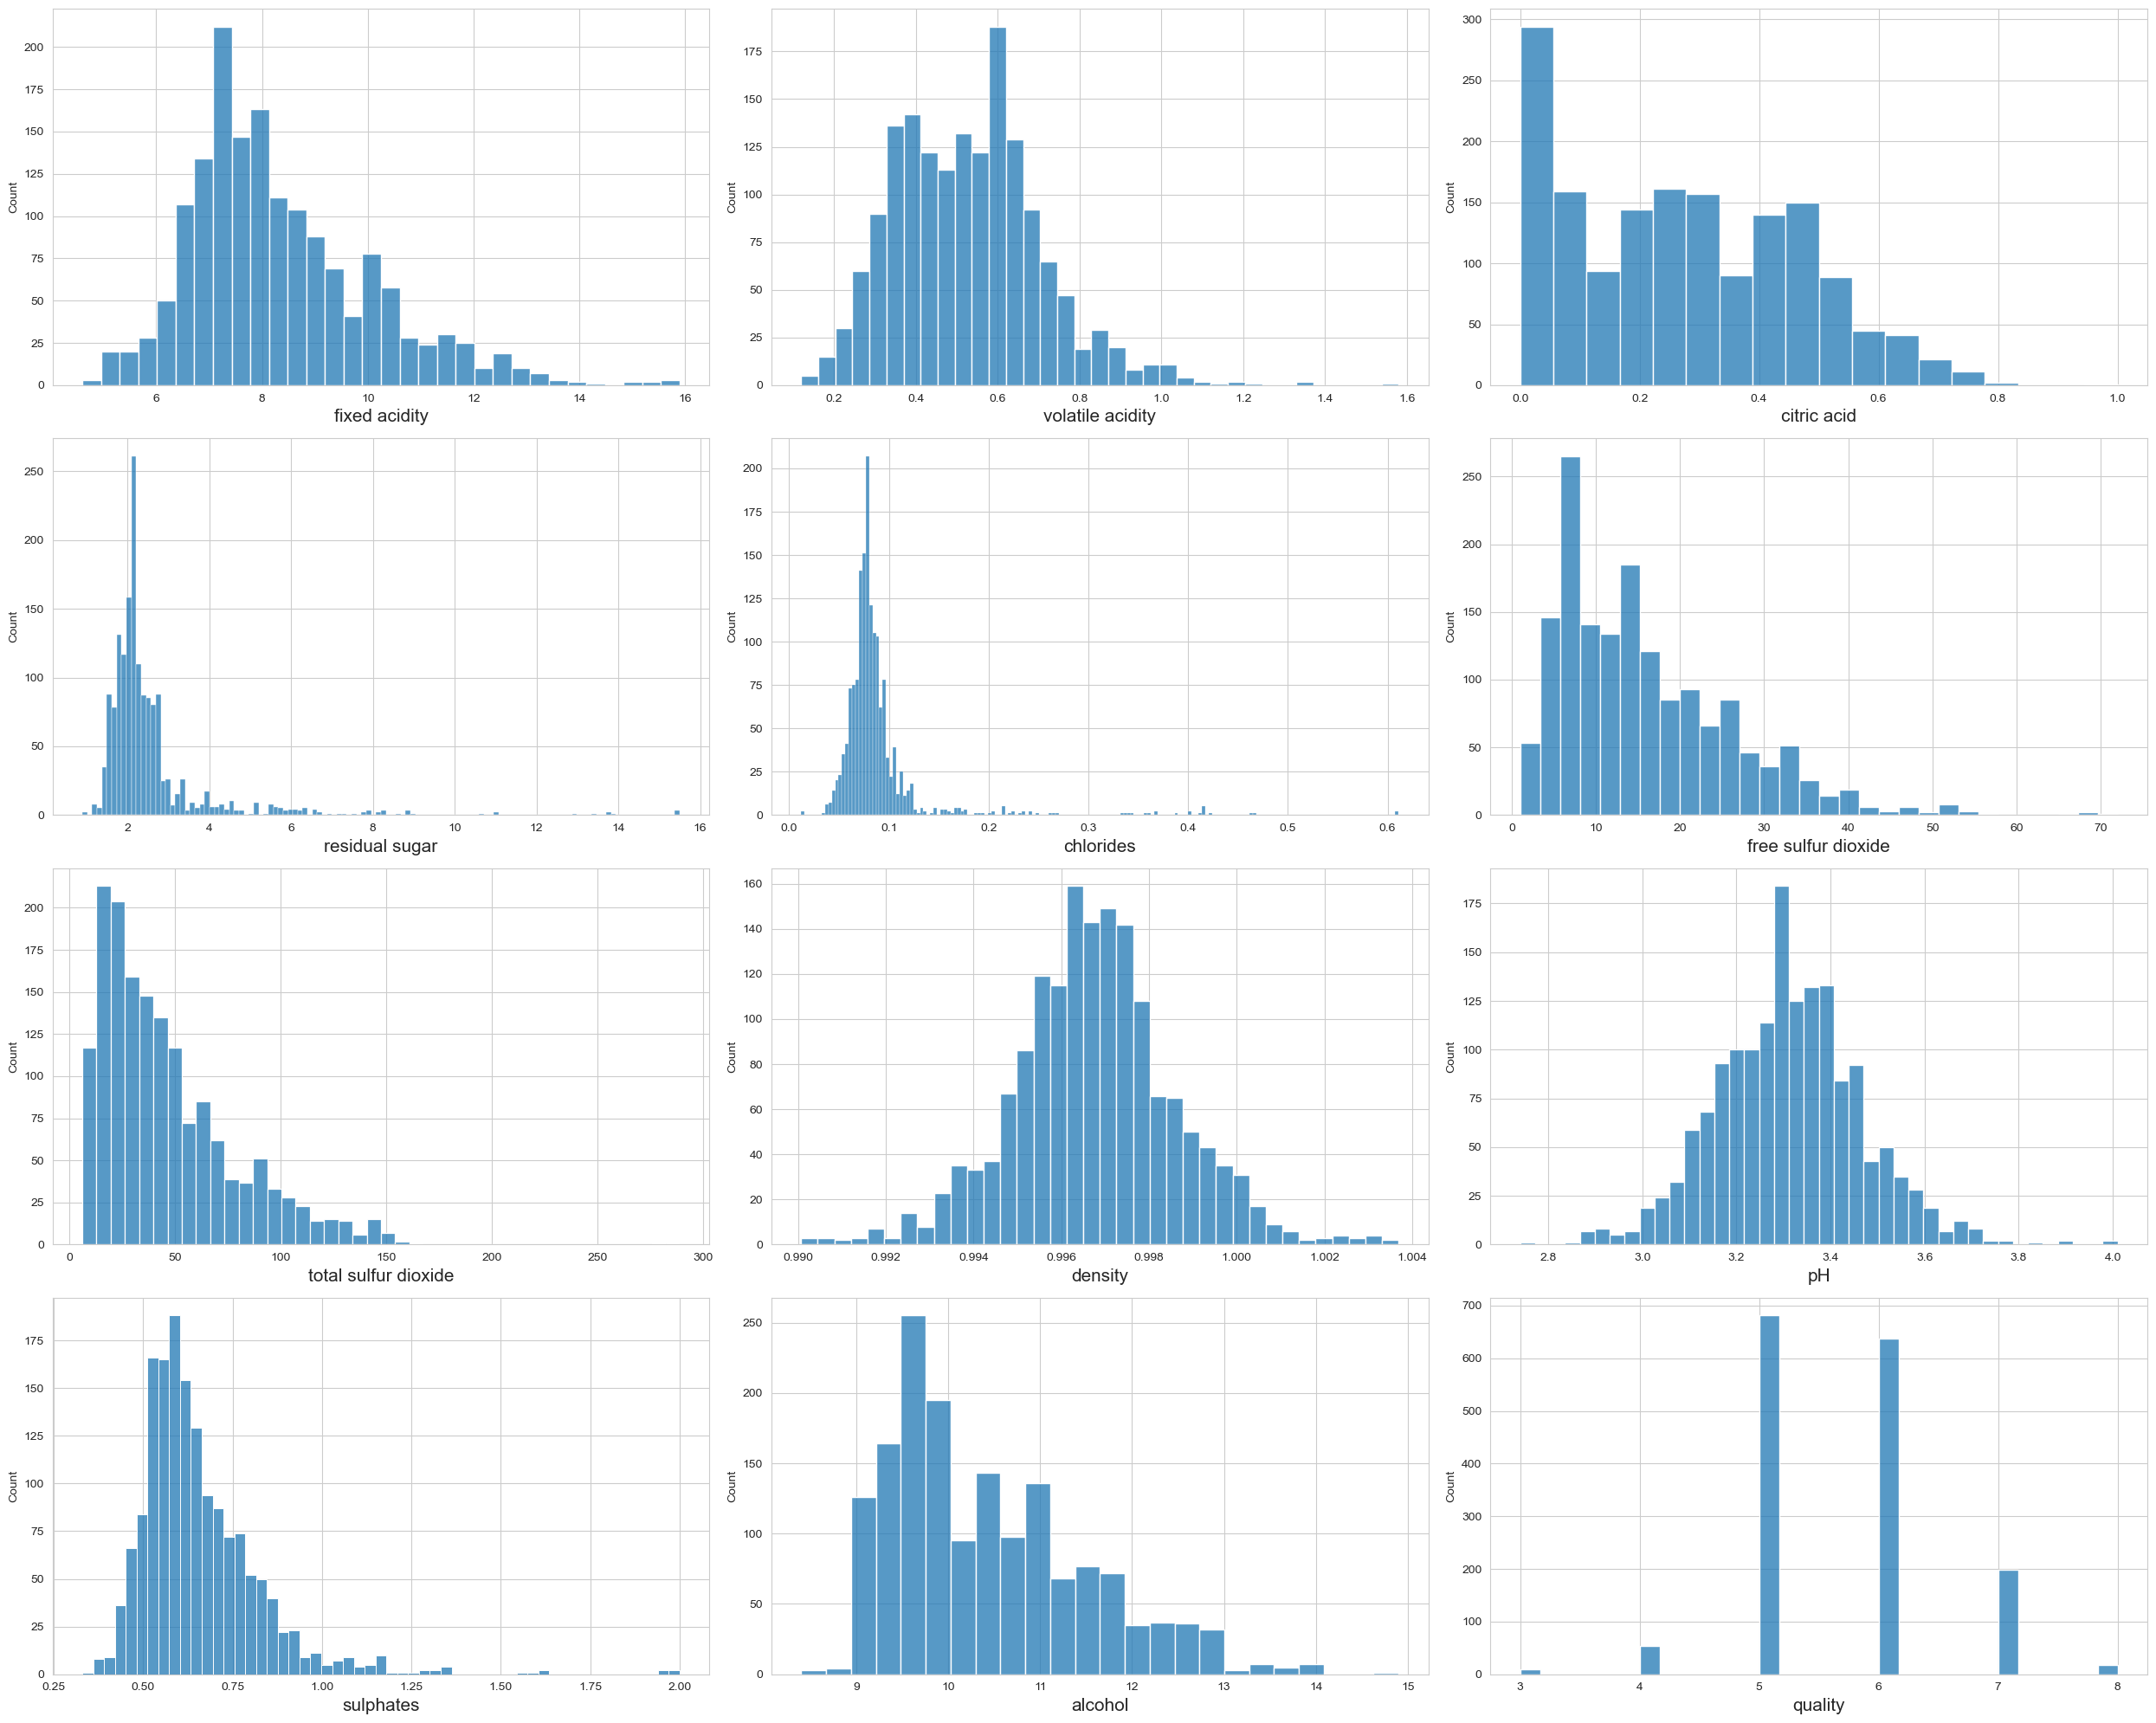

In [9]:
# let's see how data is distributed for every column
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in df:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

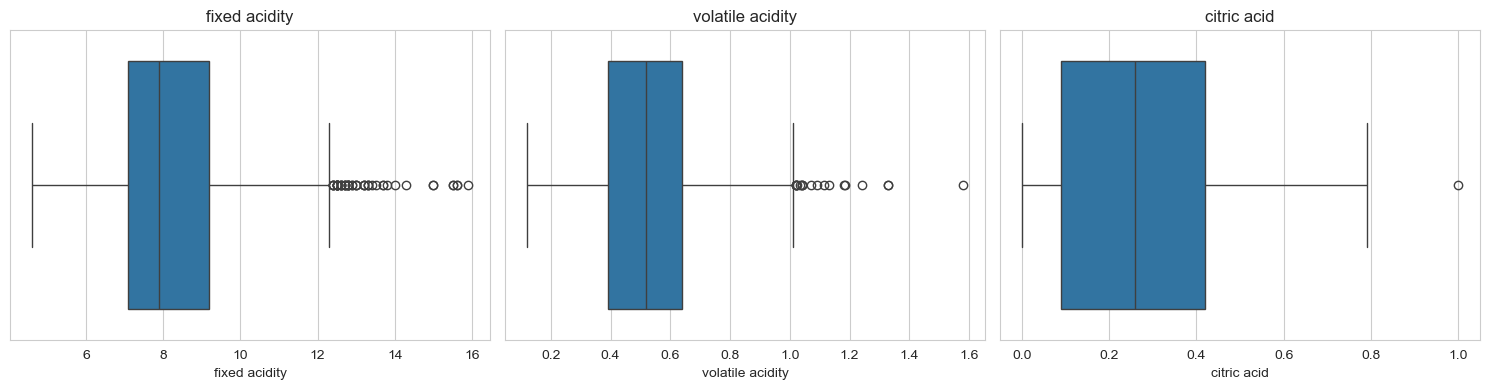

In [ ]:
# 이상치에 대해 더 알아보기 위해 박스 플롯을 활용했다.

plt.figure(figsize=(15, 4))

for i, col in enumerate(
    ["fixed acidity", "volatile acidity", "citric acid"], start=1
):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Q4. correlation plot을 그리고, 해당 plot에서 얻은 인사이트를 정리해보세요.

더불어 multicollinearity(통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제)에 주목하여, 해당 correlation plot에서 어떤 영향을 주고 있는지 있는지 예를 들어 기술하시오.

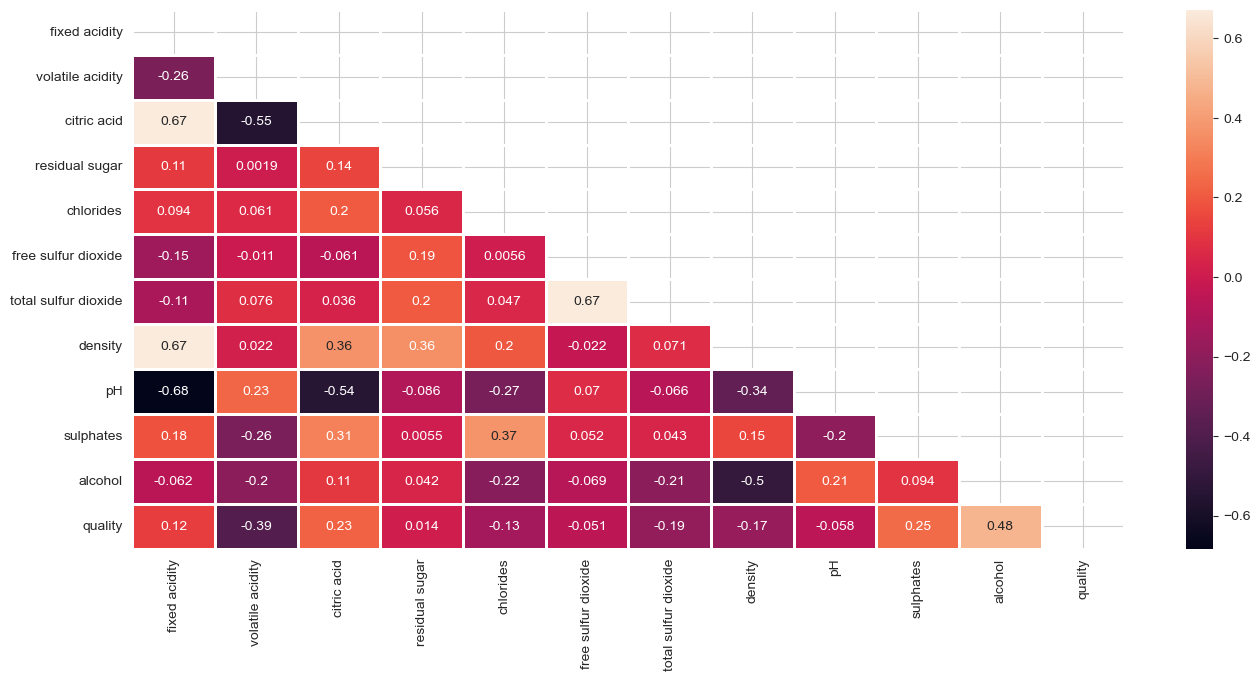

In [11]:
# 상관관계 plot
plt.figure(figsize = (16, 7))

corr = df.corr()
##에 들어갈 코드를 작성하시오.
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, annot = True, fmt = '0.2g', linewidths = 1)
plt.show()

In [12]:
#Pearson correlation coefficient
import scipy.stats as st
print("Pearson correlation coefficient:", st.pearsonr(df["alcohol"],df["density"]))
print("Pearson correlation coefficient:", st.pearsonr(df["free sulfur dioxide"],df["total sulfur dioxide"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["citric acid"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["density"]))

Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.4961797702417017), pvalue=np.float64(3.9388353399881845e-100))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6676664504810216), pvalue=np.float64(6.404722954681062e-207))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.6829781945685313), pvalue=np.float64(4.063034039843753e-220))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.5419041447395097), pvalue=np.float64(1.0072013259114937e-122))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6680472921189737), pvalue=np.float64(3.074747060860077e-207))


상관행렬은 두 변수 사이의 선형관계를 나타내며, 이번 분석에서는 Pearson
상관계수를 사용하였다. 분석 결과, 품질(`quality`)은 `alcohol`과 가장 큰
양의 상관관계(r=0.48)를 보였고, `volatile acidity`와는 비교적 큰 음의
상관관계(r=-0.39)를 보였다. 따라서 알코올 함량이 높은 와인은 품질 점수가
높고, 휘발산도가 높은 와인은 품질 점수가 낮은 경향이 있다. 

독립변수 사이에서는 `fixed acidity`와 `pH`가 음의 상관관계(r=-0.68)를
보였고, `fixed acidity`는 `citric acid` 및 `density`와 양의 상관관계
(r≈0.67)를 보였다. 또한 `free sulfur dioxide`와
`total sulfur dioxide` 사이에도 양의 상관관계(r=0.67)가 나타났다.
이는 산도나 이산화황과 관련된 정보가 여러 독립변수에 중복되어 있을
가능성을 보여준다.

다만 상관행렬은 변수를 두 개씩 비교하기 때문에 이것만으로 다중공선성을
확정할 수 없다. 이에 따라 한 변수가 나머지 독립변수들의 선형결합으로
얼마나 설명되는지를 측정하는 VIF를 추가로 계산하였다.

In [13]:
# VIF 계산 코드

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from statsmodels.tools.tools import add_constant

# 원본 df를 변경하지 않도록 독립변수만 복사
# quality는 종속변수이므로 VIF 계산에서 제외
X_vif = df.drop(columns=["quality"]).copy()

# VIF 계산을 위한 상수항 추가
X_vif_const = add_constant(X_vif)

# 상수항을 제외한 각 독립변수의 VIF 계산
vif_result = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(1, X_vif_const.shape[1])
    ]
})

vif_result = vif_result.sort_values(
    by="VIF",
    ascending=False
).reset_index(drop=True)

vif_result

,feature,VIF
0,fixed acidity,7.767512
1,density,6.343760
2,pH,3.329732
3,citric acid,3.128022
4,alcohol,3.031160
5,total sulfur dioxide,2.186813
6,free sulfur dioxide,1.963019
7,volatile acidity,1.789390
8,residual sugar,1.702588
9,chlorides,1.481932


VIF 분석 결과, `fixed acidity`의 VIF는 7.77, `density`의 VIF는
6.34로 나타나 일반적인 주의 기준인 5를 초과하였다. `fixed acidity`는
`pH`, `citric acid`, `density` 등과 관련되어 있고, `density`는
`fixed acidity`, `alcohol`, `residual sugar` 등과 관련되어 있으므로
여러 변수와 공유하는 정보가 높은 VIF로 나타난 것으로 해석할 수 있다.
나머지 변수의 VIF는 약 1.4~3.3이며, 모든 변수가 10 미만이므로
극단적으로 심각한 다중공선성은 아니지만 `fixed acidity`와 `density`의
회귀계수를 해석할 때는 주의할 필요가 있다.

다중공선성은 특히 선형회귀나 로지스틱 회귀에서 회귀계수의 표준오차를
증가시키고 계수를 불안정하게 하여 개별 변수의 영향력을 해석하기 어렵게
만들 수 있다. 향후 모델의 목적과 검증 성능을 고려하여 상관된 변수 제거,
변수 결합, 규제 모델 또는 PCA 등의 방법을 검토할 수 있다.

### Q5. quality range를 두 파트로 나눠보세요.
In this dataset quality range is between 3 and 8
We will divide quality range into two parts:



*   High quality wine: 6 - 8
*   Low quality wine: 3 - 5



In [14]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)
##에 들어갈 코드를 작성하시오.
df["quality"]

0       0
1       0
2       0
3       1
4       0
       ..
1594    0
1595    1
1596    1
1597    0
1598    1
Name: quality, Length: 1599, dtype: int64

In [16]:
# 잘 바뀌었는지 확인!

# 변환 후 가능한 값 확인
print(df["quality"].unique())

# 각 클래스의 개수 확인
print(df["quality"].value_counts())

[0 1]
quality
1    855
0    744
Name: count, dtype: int64


In [15]:
df.head().style.background_gradient(cmap = "Reds")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,0
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,0
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,1
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,0


### Q6. 종속변수(y,label)은 무엇이 되어야 하나요?


이번 분석의 목표는 와인의 화학적 특성을 이용해
고품질 여부를 분류하는 것이므로 종속변수는 `quality`이다.


In [17]:
# we select dependent variable (label)
y = df["quality"] ##을 채우시오.

# we select independent variable
x = df.drop("quality", axis = 1) ##을 채우시오.

In [18]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    shuffle = True,
                                                    random_state = 1)

### Q7. 왜 Standardization(StandardScaler, MinMaxScaler 등) 사용할까요? 


KNN은 관측값 사이의 거리를 기준으로 분류하므로 변수의 단위와 범위에
민감하다. 이 데이터에서 `total sulfur dioxide`는 수백 단위의 값을
가지지만 `density`는 약 1 부근의 값을 가진다. 스케일링하지 않으면 실제
중요도와 관계없이 값의 범위가 큰 변수가 거리 계산을 지배할 수 있으므로,
각 변수를 비교 가능한 크기로 변환할 필요가 있다.

두 Scaler의 특징에 대해 조사하고, 보다 적절한 Scaler가 무엇일지 그 이유와 함께 적어주세요.

| 구분 | MinMaxScaler | StandardScaler |
|---|---|---|
| 변환 기준 | 최솟값과 최댓값 | 평균과 표준편차 |
| 일반적 범위 | 0~1 | 제한 없음 |
| 중심 | 반드시 0이 아님 | 평균 약 0 |
| 분포 형태 | 유지 | 유지 |
| 이상치 영향 | 매우 큼 | 큼 |
| 주요 활용 | KNN, 신경망 | KNN, SVM, 선형모델 |


MinMaxScaler를 선택한 이유는 KNN이 거리 기반 모델이고, 각 변수의 범위를 0~1로 명확하게 통일할 수 있기 때문이다.


다만 일부 변수에 치우친 분포와 극단값이 관찰되므로 MinMaxScaler가 항상 최선이라고 단정할 수는 없으며, StandardScaler 또는 RobustScaler와의 교차검증 성능을 비교하여 선택하는 것이 더 확실할 것 같다.

-> 뒤에 어떤 스케일러가 좋을지 실험을 진행했다.(추가실험1)

In [19]:
# scaling data
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range = (0, 1))
norm.fit(x_train)
x_train = norm.transform(x_train)
x_test = norm.transform(x_test)

### Q7-2. 위의 코드에서, train dataset에 대해서는 fit_transform을, test dataset에 대해서는 transform을 실시하는 이유가 무엇일지 조사해주세요.

`fit()`은 데이터를 변환하기 위한 기준을 학습하고, `transform()`은
학습한 기준을 데이터에 적용한다. MinMaxScaler에서 `fit()`은 훈련
데이터의 변수별 최솟값과 최댓값을 계산하며, `fit_transform()`은 이
기준을 학습한 후 훈련 데이터를 바로 변환한다.

테스트 데이터는 학습에 사용되지 않은 새로운 데이터를 모사하므로 테스트
데이터의 최솟값과 최댓값을 다시 학습해서는 안 된다. 테스트 데이터에
`fit_transform()`을 사용하면 테스트 데이터의 분포 정보가 전처리 과정에
사용되는 데이터 누수가 발생하고, 훈련 데이터와 테스트 데이터가 서로 다른
기준으로 변환된다.

따라서 훈련 데이터에는 `fit_transform()`을 사용하고, 테스트 데이터에는
훈련 데이터에서 학습한 동일한 기준을 적용하는 `transform()`만 사용해야
한다.

In [20]:
print(x_train[0:5])
print("\n")
print(x_train.shape)
print("_________________________________________________________________________")
print(x_test[0:5])
print("\n")
print(x_test.shape)

[[0.23893805 0.1369863  0.23       0.10769231 0.090301   0.47887324
  0.23529412 0.4441896  0.54330709 0.17365269 0.26153846]
 [0.32743363 0.38013699 0.26       0.09230769 0.12040134 0.14084507
  0.13602941 0.57568807 0.4488189  0.11976048 0.12307692]
 [0.69911504 0.17808219 0.6        0.13076923 0.11538462 0.42253521
  0.24264706 0.72859327 0.28346457 0.23952096 0.32307692]
 [0.36283186 0.44178082 0.22       0.10769231 0.08695652 0.11267606
  0.13235294 0.47629969 0.28346457 0.13173653 0.15384615]
 [0.32743363 0.49657534 0.01       0.1        0.09698997 0.05633803
  0.02941176 0.50688073 0.45669291 0.1497006  0.4       ]]


(1199, 11)
_________________________________________________________________________
[[0.37168142 0.19863014 0.64       0.1        0.13545151 0.11267606
  0.13235294 0.65214067 0.62992126 0.19760479 0.32307692]
 [0.36283186 0.34931507 0.28       0.13846154 0.14046823 0.22535211
  0.23161765 0.5558104  0.40944882 0.17964072 0.27692308]
 [0.51327434 0.15068493 0.58  

In [21]:
print(y_train.head())
print(y_train.shape)
print("___________________________")
print(y_test.head())
print(y_test.shape)

1144    0
73      0
446     0
399     0
647     0
Name: quality, dtype: int64
(1199,)
___________________________
75      0
1283    1
408     1
1281    1
1118    1
Name: quality, dtype: int64
(400,)


### Q8. Building Classification models

이번 코드에서는 non parametric model; knn을 사용하여 train, test 진행해보았습니다.

아래의 코드 외에도 원하는 한가지 classification 모델(KNN 제외)을 선정하여 아래의 과정을 반복하고, 그 결과를 해석하세요. grid search 과정은 거치지 않고 임의의 파라미터값으로 진행해도 좋습니다.

아래와 같은 Kaggle 코드들도 참고해보세요.  
- https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification/notebook
- https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


In [ ]:
## 아래의 과정을 반복하시오.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
#KNN

knn = KNeighborsClassifier()

knn_params = {"n_neighbors": np.arange(2, 50),
             "weights": ["uniform", "distance"],
             "leaf_size": [25, 30, 35]} # 25가 중복이라 하나를 35로 바꿨습니다~

knn_cv_model = GridSearchCV(knn, knn_params, cv = 10)
knn_cv_model.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [25, 30, 35],
                         'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'weights': ['uniform', 'distance']})

코드의 의미와 결과 해석

GridSearchCV: 사용자가 지정한 하이퍼파라미터 조합을 모두 시험하고, 교차검증 점수가 가장 좋은 조합을 선택한다.
- leaf_size: 가까운 이웃을 효율적으로 찾기 위해 데이터를 관리하는 묶음의 크기이다. 예측 결과에는 영향이 거의 없으나 검색 속도와 메모리 사용량이 달라질 수 있다.
- n_neighbor: 새로운 와인의 품질을 예측할 때 스케일링된 특성 공간에서 가장 가까운 훈련 와인 n개를 참고한다.
- weights: 더 가까운 이웃에 더 큰 가산점을 줄지 여부이다.

여기에서는 각각 25(25개씩 관리 - 정확도에는 의미 거의 없음), 21(주변 이웃 21개 참고), distance(거리별 가산점 있음)일 때의 조합이 가장 좋게 나왔다.

In [23]:
print("Best score for train set: " + str(knn_cv_model.best_score_))

print("____________________________________________")

print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


In [24]:
knn_model = KNeighborsClassifier(n_neighbors = knn_cv_model.best_params_["n_neighbors"],
                                leaf_size = knn_cv_model.best_params_["leaf_size"],
                                weights = knn_cv_model.best_params_["weights"])

knn_model.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=25, n_neighbors=np.int64(21), weights='distance')

In [25]:
from sklearn.metrics import accuracy_score
y_pred = knn_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred)) #Validation Set Accurac

Accuracy: 0.8025


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



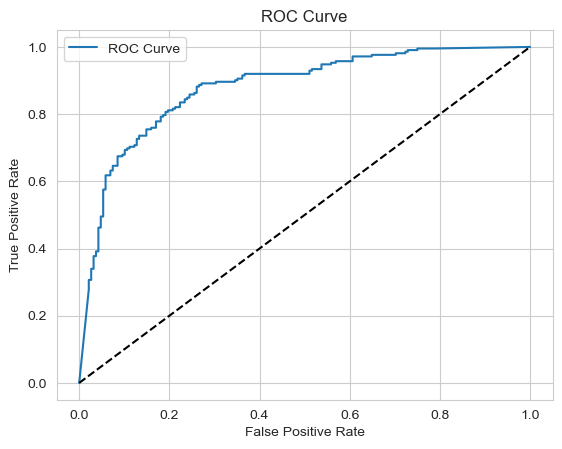

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
# Validation Set 에 대한 예측확률 계산
y_prob = knn_model.predict_proba(x_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 추가실험1: 정말 MinMax 방식이 최선이었을까?

In [28]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# 1. 실험용 원본 데이터 준비
# 기존 x_train, x_test에는 영향을 주지 않음
# --------------------------------------------------
X_exp = df.drop(columns=["quality"]).copy()
y_exp = df["quality"].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = (
    train_test_split(
        X_exp,
        y_exp,
        test_size=0.25,
        random_state=1,
        shuffle=True,
        stratify=y_exp
    )
)

# --------------------------------------------------
# 2. 비교할 스케일링 방법
# --------------------------------------------------
scalers = {
    "No Scaling": "passthrough",
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

# 모든 스케일러에 동일한 fold 적용
cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=1
)

experiment_results = []

# --------------------------------------------------
# 3. 스케일러별 KNN 성능 측정
# --------------------------------------------------
for scaler_name, scaler in scalers.items():

    pipeline = Pipeline([
        ("scaler", scaler),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=21,
                weights="distance",
                leaf_size=25
            )
        )
    ])

    # 훈련 데이터 내부의 10-fold 교차검증
    cv_scores = cross_validate(
        pipeline,
        X_train_exp,
        y_train_exp,
        cv=cv_strategy,
        scoring="accuracy",
        return_train_score=False
    )["test_score"]

    # 참고용 최종 테스트 정확도
    pipeline.fit(X_train_exp, y_train_exp)
    test_pred = pipeline.predict(X_test_exp)
    test_accuracy = accuracy_score(
        y_test_exp,
        test_pred
    )

    experiment_results.append({
        "Scaler": scaler_name,
        "Mean CV Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Test Accuracy": test_accuracy
    })

# 결과표 생성
scaler_results = pd.DataFrame(
    experiment_results
).sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(drop=True)

scaler_results

,Scaler,Mean CV Accuracy,CV Std,Test Accuracy
0,MinMaxScaler,0.793964,0.037477,0.7800
1,StandardScaler,0.793137,0.032184,0.8125
2,RobustScaler,0.786464,0.026629,0.7950
3,No Scaling,0.745602,0.032485,0.7250


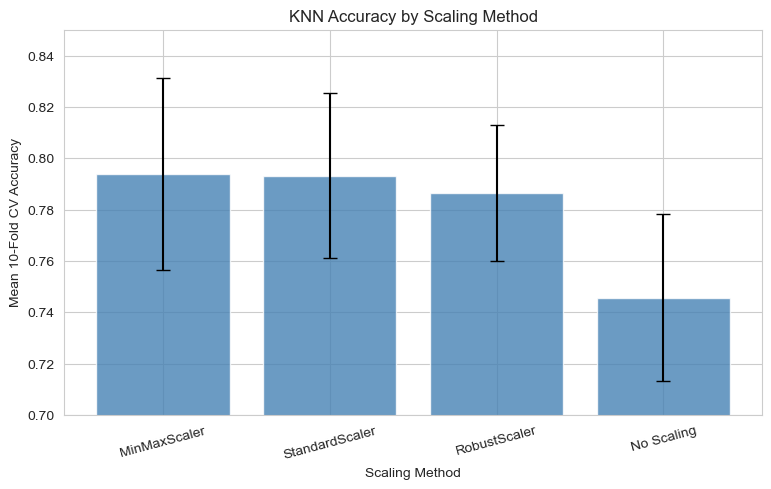

In [ ]:
# 결과 시각화 with 불확실성

plt.figure(figsize=(9, 5))

plt.bar(
    scaler_results["Scaler"],
    scaler_results["Mean CV Accuracy"],
    yerr=scaler_results["CV Std"],
    capsize=5,
    color="steelblue",
    alpha=0.8
)

plt.ylim(0.70, 0.85)
plt.xlabel("Scaling Method")
plt.ylabel("Mean 10-Fold CV Accuracy")
plt.title("KNN Accuracy by Scaling Method")
plt.xticks(rotation=15)
plt.show()

KNN은 변수 사이의 거리를 기준으로 분류하므로 스케일링 방법에 따른 성능
차이를 확인하였다. 스케일러의 효과만 비교하기 위해 동일한 훈련 데이터와
10-fold 교차검증을 사용하고, KNN의 하이퍼파라미터는
`n_neighbors=21`, `weights='distance'`, `leaf_size=25`로 고정하였다.

실험 결과 스케일링하지 않은 경우의 평균 교차검증 정확도는 약 0.746인
반면, MinMaxScaler는 약 0.794, StandardScaler는 약 0.793,
RobustScaler는 약 0.786으로 나타났다. 이를 통해 측정 단위와 범위가
다른 원본 변수를 그대로 사용하면 특정 변수가 거리 계산을 지배하여 KNN의
성능이 낮아질 수 있으며, 스케일링이 성능 향상에 도움이 된다는 것을
확인하였다.

MinMaxScaler의 평균 정확도가 가장 높았지만 StandardScaler와의 차이는
약 0.001 미만으로 매우 작았으며, 교차검증 표준편차보다 훨씬 작았다.
따라서 MinMaxScaler가 확실히 우수하다고 단정하기보다는 두 방법이 거의
비슷한 검증 성능을 보였다고 해석하는 것이 적절하다. RobustScaler는
평균 정확도는 조금 낮았지만 fold별 성능 변동이 상대적으로 작게 나타났다.

# 추가실험2: 로지스틱 회귀를 통한 분류
거리 기반 비모수 모델인 KNN과 선형 확률 모델인 로지스틱 회귀의
분류 성능을 비교해보겠다.

In [ ]:
# 모델 학습과 예측

from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 생성
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=1
)

# 훈련 데이터로 모델 학습
logistic_model.fit(x_train, y_train)

# 테스트 데이터의 클래스 예측
logistic_pred = logistic_model.predict(x_test)

# 테스트 데이터가 고품질(1)일 확률
logistic_prob = logistic_model.predict_proba(
    x_test
)[:, 1]

In [ ]:
# 정확도 구하기

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "Low quality",
            "High quality"
        ],
        digits=3
    )
)

Logistic Regression Accuracy: 0.7375

Classification Report
              precision    recall  f1-score   support

 Low quality      0.706     0.755     0.730       188
High quality      0.769     0.722     0.745       212

    accuracy                          0.738       400
   macro avg      0.738     0.739     0.737       400
weighted avg      0.740     0.738     0.738       400



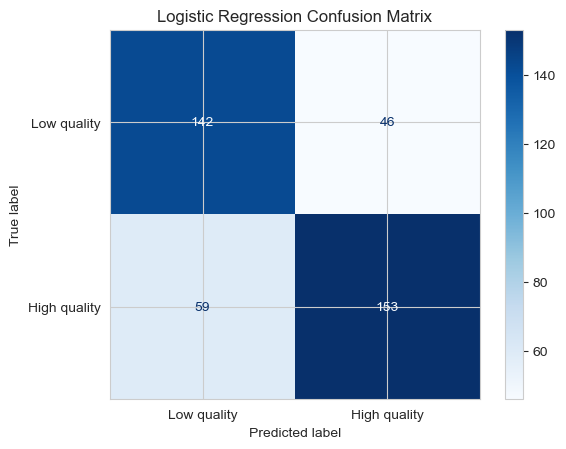

In [ ]:
# 검증: confusion matrix

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=[
        "Low quality",
        "High quality"
    ]
)

display.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

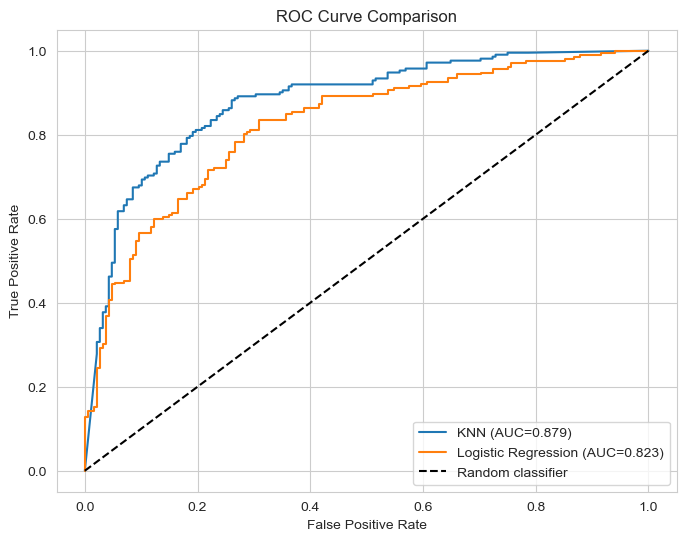

In [ ]:
# kNN과의 비교: ROC curve

# KNN
knn_fpr, knn_tpr, _ = roc_curve(
    y_test,
    y_prob
)

knn_auc = roc_auc_score(
    y_test,
    y_prob
)

# Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    knn_fpr,
    knn_tpr,
    label=f"KNN (AUC={knn_auc:.3f})"
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=(
        "Logistic Regression "
        f"(AUC={logistic_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 결과 정리
KNN과 다른 원리의 분류 모델을 비교하기 위해 로지스틱 회귀를 추가로
적용하였다. 

실험 결과 로지스틱 회귀의 테스트 정확도는 약 0.738, ROC-AUC는 약
0.823으로 나타났다. 고품질 클래스의 precision은 약 0.769,
recall은 약 0.722, F1-score는 약 0.745였다. 즉 모델이 고품질이라고
예측한 와인 중 약 76.9%가 실제 고품질이었으며, 전체 고품질 와인 중 약
72.2%를 찾아냈다.

동일한 테스트 데이터에서 KNN은 약 0.803의 정확도와 약 0.879의
ROC-AUC를 보여 로지스틱 회귀보다 높은 성능을 기록했다. 이는 와인의
화학적 특성과 품질 사이에 단순한 선형 결정경계로 표현하기 어려운
비선형적 또는 국소적인 패턴이 존재하며, 가까운 관측값을 이용하는 KNN이
이를 더 잘 반영했을 가능성을 보여준다.

다만 KNN은 GridSearchCV로 하이퍼파라미터를 선택한 반면 로지스틱 회귀는
임의의 설정으로 학습했기 때문에 두 모델의 비교가 완전히 대등한 것은
아니다. 또한 단일 테스트 분할의 결과만으로 모델의 우열을 일반화할 수
없으므로, 더욱 엄밀한 비교를 위해서는 동일한 교차검증 조건에서 두 모델의
평균 성능과 변동성을 함께 비교해야 한다.